In [36]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

df = pd.read_csv('../data/df-prepared.csv')

In [37]:
df['Cargo type'].value_counts()

Cargo type
No additional information    456001
Category X                    43039
Reserved for future use       10042
Category Y                     7272
Category OS                    3693
Category Z                     2587
Name: count, dtype: int64

https://datalastic.com/blog/the-different-hazard-levels-through-ship-api/

- Category X - Pavojingas, sprogus krovinys (which applies to Large pressure vessels (e.g. 4000-tonne ethane vessels, 7000-tonne butane or propane vessels, 25 000 tonne ammonia vessels, 200-tonne chlorine vessels, and large power boilers))
- Category Y - Transporto priemonės ir šildytuvai (boilers)
- Category Z ir OS - Maža ir mažo slėgio įranga
- No additional information - nėra pavojau
- Reserved for future use - nepakrautas laivas

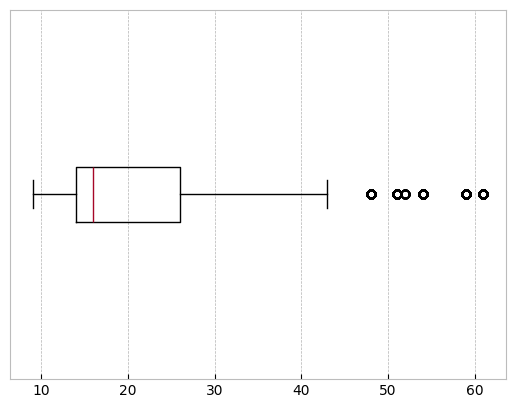

In [45]:
plt.boxplot(df['Width'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

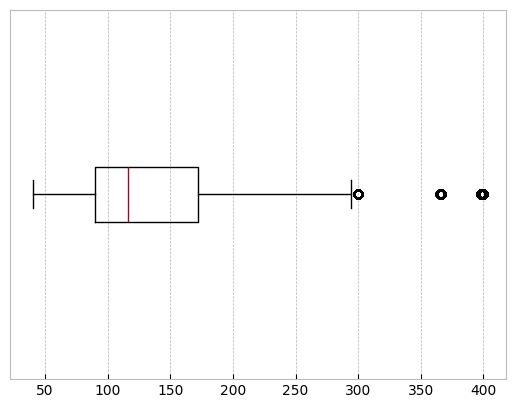

In [ ]:
plt.boxplot(df['Length'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

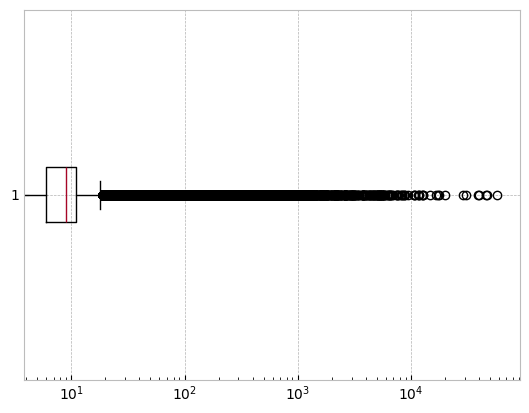

In [50]:
import numpy as np
gaps = np.load('../output/gaps.npy')
gaps = gaps[ ~np.isnan(gaps) ] * 60
plt.boxplot( gaps, orientation='horizontal' )
plt.xscale('log')

In [55]:
q1, q3 = np.quantile(gaps, q=[0.025, 0.975])
q1, q3

(np.float64(1.0), np.float64(22.0))

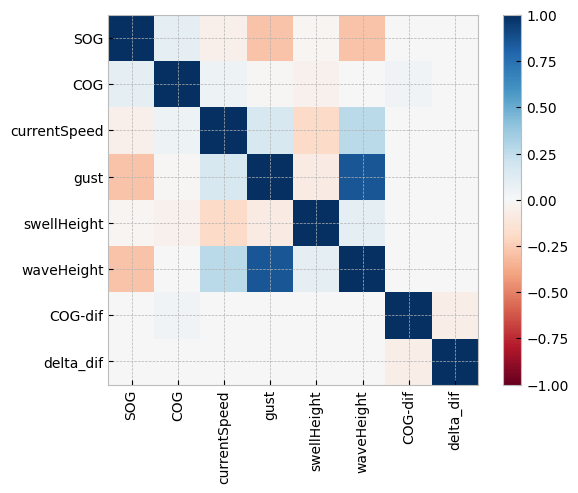

In [64]:
numeric_cols =[
    'SOG',
    'COG',
    # 'Width',
    # 'Length',
    'currentSpeed',
    'gust',
    'swellHeight',
    'waveHeight',
    'COG-dif',
    'delta_dif'
] 
plt.imshow( df[numeric_cols]\
    .corr(method='spearman'), vmin=-1.0, vmax=1.0, cmap='RdBu')

plt.colorbar()
plt.xticks(ticks=range(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(ticks=range(len(numeric_cols)), labels=numeric_cols)

plt.show()